In [1]:
# Load libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
# Position us in the uppest directory

import os
os.chdir('..')

In [7]:
# Load dataset

df = pd.read_csv('data/dataset/x_test.csv')

In [15]:
# Dataset shape

print(df.shape)

(109379, 321)


In [22]:
# Number of rows that contain Nan
print("Number of rows that contain Nan : ", df.isnull().any(axis=1).sum())

# Number of columns that contain Nan
print("Number of columns that contain Nan : ", df.isnull().any().sum())

Number of rows that contain Nan :  109379
Number of columns that contain Nan :  232


In [24]:
# Number of columns where there are more than 50% of Nan
print('Number of columns where there are more than 50% of Nan: ', df.isnull().sum(axis=0)[df.isnull().sum(axis=0) > df.shape[0]/2].shape[0])

# Number of columns where there are more than 75% of Nan
print('Number of columns where there are more than 75% of Nan: ', df.isnull().sum(axis=0)[df.isnull().sum(axis=0) > df.shape[0]*3/4].shape[0])

# Number of columns where there are more than 90% of Nan
print('Number of columns where there are more than 90% of Nan: ', df.isnull().sum(axis=0)[df.isnull().sum(axis=0) > df.shape[0]*9/10].shape[0])

# Number of columns where there are 100% of Nan
print('Number of columns where there are 100% of Nan: ', df.isnull().sum(axis=0)[df.isnull().sum(axis=0) == df.shape[0]].shape[0])

Number of columns where there are more than 50% of Nan:  147
Number of columns where there are more than 75% of Nan:  117
Number of columns where there are more than 90% of Nan:  99
Number of columns where there are 100% of Nan:  0


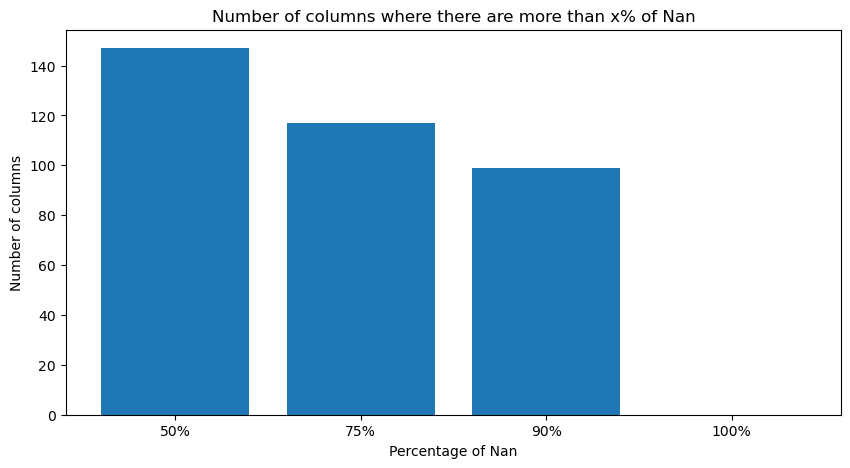

In [26]:
# Plot the values computed in the previous cell

plt.figure(figsize=(10, 5))
plt.bar(['50%', '75%', '90%', '100%'], 
        [df.isnull().sum(axis=0)[df.isnull().sum(axis=0) > df.shape[0]/2].shape[0], 
         df.isnull().sum(axis=0)[df.isnull().sum(axis=0) > df.shape[0]*3/4].shape[0], 
         df.isnull().sum(axis=0)[df.isnull().sum(axis=0) > df.shape[0]*9/10].shape[0], 
         df.isnull().sum(axis=0)[df.isnull().sum(axis=0) == df.shape[0]].shape[0]])

plt.title('Number of columns where there are more than x% of Nan')
plt.xlabel('Percentage of Nan')
plt.ylabel('Number of columns')
plt.show()

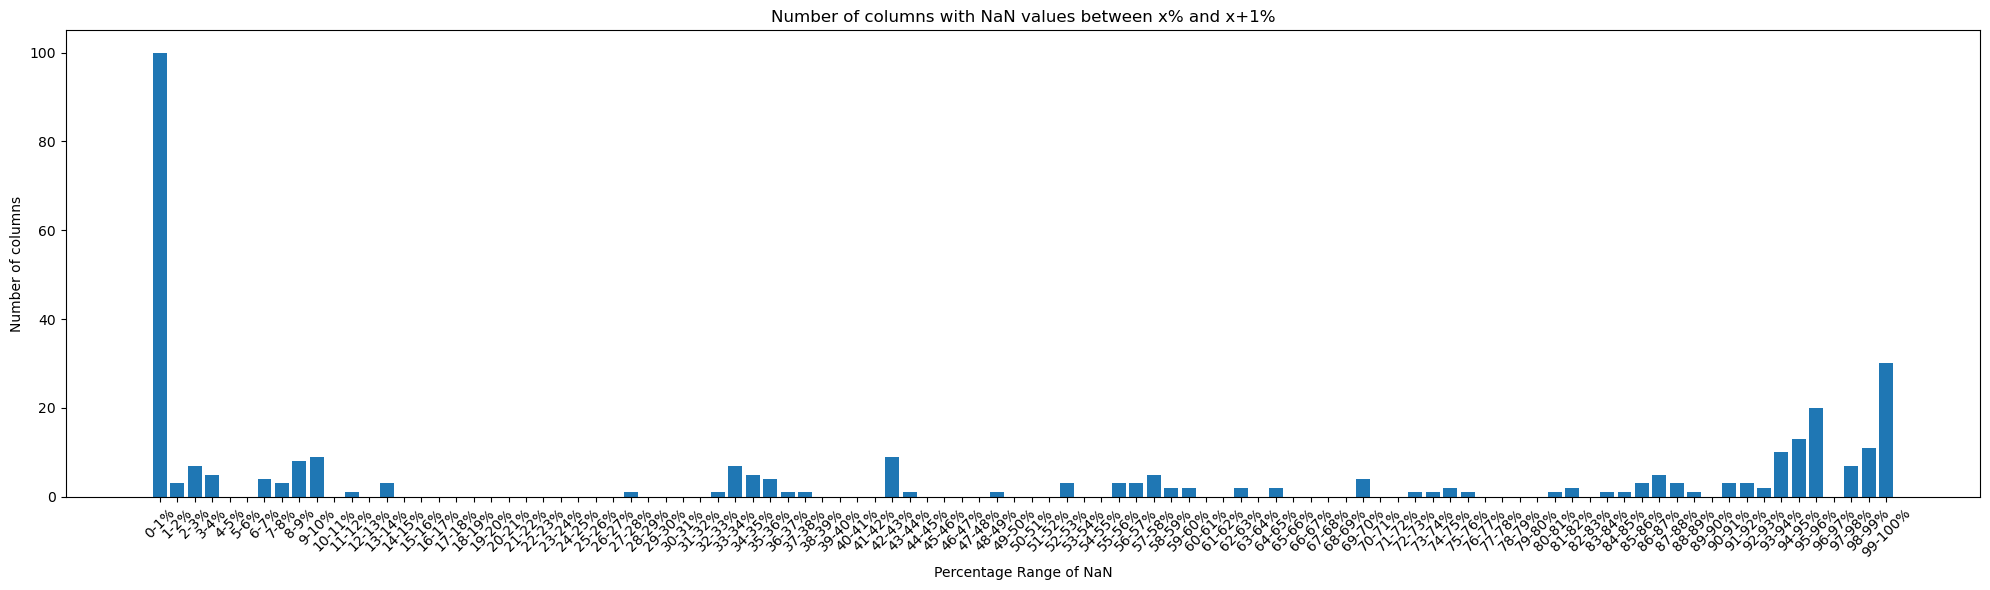

In [39]:
# Liste de percentiles à examiner
percentiles = list(range(101))

# Calcul du nombre de colonnes ayant un pourcentage de NaN entre x% et (x+1)%
num_columns_with_percentile_nans = [
    df.isnull().sum(axis=0)[
        (df.isnull().sum(axis=0) >= df.shape[0]*p/100) &
        (df.isnull().sum(axis=0) < df.shape[0]*(p+1)/100)
    ].shape[0] for p in percentiles[:-1]  # Exclude the last percentile (100%)
]

# Labels for the x-axis
percentile_labels = [f'{p}-{p+1}%' for p in percentiles[:-1]]

# Affichage du graphique
plt.figure(figsize=(20, 6))
plt.bar(percentile_labels, num_columns_with_percentile_nans)

plt.title('Number of columns with NaN values between x% and x+1%')
plt.xlabel('Percentage Range of NaN')
plt.ylabel('Number of columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


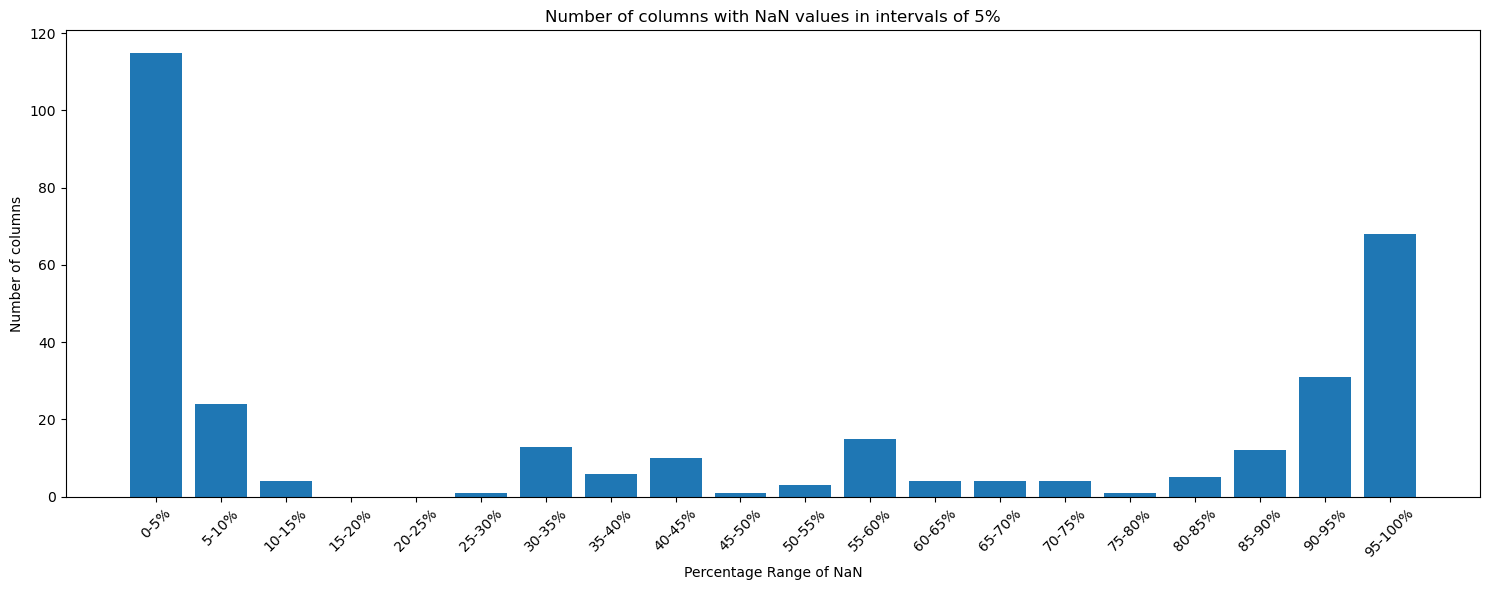

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Liste de percentiles à examiner (de 0 à 100 par pas de 5)
percentiles = list(range(0, 101, 5))

# Calcul du nombre de colonnes ayant un pourcentage de NaN entre x% et (x+5)%
num_columns_with_percentile_nans = [
    df.isnull().sum(axis=0)[
        (df.isnull().sum(axis=0) >= df.shape[0]*p/100) &
        (df.isnull().sum(axis=0) < df.shape[0]*(p+5)/100)
    ].shape[0] for p in percentiles[:-1]  # Exclude the last percentile (100%)
]

# Labels for the x-axis
percentile_labels = [f'{p}-{p+5}%' for p in percentiles[:-1]]

# Affichage du graphique
plt.figure(figsize=(15, 6))
plt.bar(percentile_labels, num_columns_with_percentile_nans)

plt.title('Number of columns with NaN values in intervals of 5%')
plt.xlabel('Percentage Range of NaN')
plt.ylabel('Number of columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
